# Finite-Element Laplace Solver in 2D  
## A gentle starter notebook for electrostatic potentials, boundary conditions, and model-order reduction

This notebook solves the **Laplace equation**

\[
$\nabla^2 V(x,y) = 0$
\]

inside a rectangular 2D box. The unknown \(V(x,y)\) is the **electric potential**. Once we know \(V\), the electric field is

\[
$\mathbf{E}(x,y) = -\nabla V(x,y).$
\]

The goal is to generate many solutions for continuously changing boundary conditions, collect them as **snapshots**, and later use tools such as **SVD**, **POD**, or the **reduced basis method** to build a fast emulator.

Think of the notebook as a tiny electrostatic wind tunnel 🪁: we keep changing the voltages on the boundary, solve the field inside the box, and save the shapes of the resulting solutions.

## 1. Physics idea

In electrostatics, if there is no charge density inside the box, the potential satisfies

\[
\n$abla^2 V = 0.$
\]

This says that the value of \(V\) at any interior point is, in a precise mathematical sense, an average of the surrounding values. There are no sources or sinks inside the domain.

The boundary conditions tell the problem what voltages are imposed on the edges of the box. For example:

- left wall at \(1\ \mathrm{V}\),
- right wall at \(0\ \mathrm{V}\),
- top and bottom walls maybe varying smoothly.

Different boundary voltages produce different interior potential landscapes.

## 2. Numerical idea: finite elements with triangles

We divide the rectangular box into many small triangles. On each triangle, we approximate the potential by a simple linear function.

The weak form of Laplace's equation leads to a linear system

\[
K \mathbf{v} = \mathbf{f},
\]

where:

- \(\mathbf{v}\) contains the unknown potential values at the mesh nodes,
- \(K\) is the stiffness matrix,
- \(\mathbf{f}\) is zero here because there is no charge inside the domain.

For a single triangular element, the local stiffness matrix is

\[
$K_{ij}^{(e)} = \int_{\Omega_e} \nabla \phi_i \cdot \nabla \phi_j \, dA,$
\]

where \(\phi_i\) are the triangle's basis functions.

For linear triangular elements, the gradients are constant inside each triangle, which makes this pleasantly compact.

In [1]:
# Core numerical imports
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Plotting imports
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# A small convenience for reproducible-looking plots
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "font.size": 11,
})

## 3. Build a triangular mesh for a rectangular box

We will use a structured grid of points and split each rectangle into two triangles.

The domain is

\[
$0 \le x \le L_x, \qquad 0 \le y \le L_y.$
\]

Increasing `nx` and `ny` gives a more accurate solution, at the cost of a larger linear system.

In [2]:
def make_rectangular_tri_mesh(Lx=1.0, Ly=1.0, nx=40, ny=40):
    """
    Create a simple triangular mesh on a rectangle.

    Parameters
    ----------
    Lx, Ly : float
        Width and height of the rectangular domain.
    nx, ny : int
        Number of grid points in x and y.
        The total number of nodes is nx * ny.

    Returns
    -------
    points : ndarray, shape (N, 2)
        Coordinates of mesh nodes.
    triangles : ndarray, shape (M, 3)
        Indices of the three vertices of each triangle.
    boundary : dict
        Boolean masks identifying nodes on each boundary.
    """
    x = np.linspace(0.0, Lx, nx)
    y = np.linspace(0.0, Ly, ny)
    X, Y = np.meshgrid(x, y, indexing="xy")

    points = np.column_stack([X.ravel(), Y.ravel()])

    def node_id(i, j):
        """Map grid indices (i, j) to the flattened node index."""
        return j * nx + i

    triangles = []

    for j in range(ny - 1):
        for i in range(nx - 1):
            n00 = node_id(i, j)
            n10 = node_id(i + 1, j)
            n01 = node_id(i, j + 1)
            n11 = node_id(i + 1, j + 1)

            # Split each square cell into two triangles.
            # The choice of diagonal is arbitrary for this simple demo.
            triangles.append([n00, n10, n11])
            triangles.append([n00, n11, n01])

    triangles = np.array(triangles, dtype=int)

    tol = 1e-14
    boundary = {
        "left":   np.isclose(points[:, 0], 0.0, atol=tol),
        "right":  np.isclose(points[:, 0], Lx, atol=tol),
        "bottom": np.isclose(points[:, 1], 0.0, atol=tol),
        "top":    np.isclose(points[:, 1], Ly, atol=tol),
    }

    boundary["all"] = (
        boundary["left"] | boundary["right"] |
        boundary["bottom"] | boundary["top"]
    )

    return points, triangles, boundary

## 4. Assemble the finite-element stiffness matrix

For each triangle, we compute the gradients of the three linear basis functions.

For a triangle with vertices \((x_1,y_1)\), \((x_2,y_2)\), and \((x_3,y_3)\), each basis function is linear:

\[
\phi_i(x,y) = a_i + b_i x + c_i y.
\]

Therefore,

\[
\nabla \phi_i = (b_i, c_i)
\]

is constant inside the triangle.

The local stiffness matrix is

\[
K_{ij}^{(e)} = A_e \, \nabla \phi_i \cdot \nabla \phi_j,
\]

where \(A_e\) is the triangle area.

In [3]:
def triangle_area_and_gradients(coords):
    """
    Compute the area of a triangle and the gradients of its three linear basis functions.

    Parameters
    ----------
    coords : ndarray, shape (3, 2)
        Coordinates of the triangle vertices.

    Returns
    -------
    area : float
        Area of the triangle.
    grads : ndarray, shape (3, 2)
        grads[i] is the gradient of basis function phi_i.
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]

    detJ = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)
    area = abs(detJ) / 2.0

    if area <= 0:
        raise ValueError("Triangle has zero or negative area.")

    # Coefficients for gradients of linear basis functions.
    # grad(phi_i) = [b_i, c_i] / detJ, where detJ carries the triangle orientation.
    grads = np.array([
        [y2 - y3, x3 - x2],
        [y3 - y1, x1 - x3],
        [y1 - y2, x2 - x1],
    ], dtype=float) / detJ

    return area, grads


def assemble_stiffness_matrix(points, triangles):
    """
    Assemble the global finite-element stiffness matrix for Laplace's equation.

    Parameters
    ----------
    points : ndarray, shape (N, 2)
        Mesh node coordinates.
    triangles : ndarray, shape (M, 3)
        Triangle connectivity.

    Returns
    -------
    K : scipy sparse CSR matrix, shape (N, N)
        Global stiffness matrix.
    """
    N = len(points)

    rows = []
    cols = []
    data = []

    for tri in triangles:
        coords = points[tri]
        area, grads = triangle_area_and_gradients(coords)

        # Local element matrix: K_ij = area * dot(grad phi_i, grad phi_j)
        Ke = area * (grads @ grads.T)

        for local_i, global_i in enumerate(tri):
            for local_j, global_j in enumerate(tri):
                rows.append(global_i)
                cols.append(global_j)
                data.append(Ke[local_i, local_j])

    K = sp.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()
    return K

## 5. Boundary conditions

We use **Dirichlet boundary conditions**, meaning that we directly prescribe the voltage \(V\) on the boundary.

To make the problem easy to change continuously, we define a function

```python
boundary_voltage(x, y, params)
```

where `params` contains tunable knobs.

Below is one example family:

\[
V_{\mathrm{top}}(x) = A_{\mathrm{top}}\sin(\pi x/L_x),
\]

with constant voltages on the other walls. By changing \(A_{\mathrm{top}}\), or the wall voltages, we generate a family of solutions.

In [4]:
def example_boundary_voltage(x, y, params):
    """
    Example boundary condition family.

    Parameters
    ----------
    x, y : float or ndarray
        Coordinates where the boundary voltage is evaluated.
    params : dict
        Parameters controlling the boundary condition.

    Returns
    -------
    Vb : float or ndarray
        Boundary voltage at the requested point(s).

    Notes
    -----
    This function assumes a rectangular domain with x in [0, Lx] and y in [0, Ly].

    The boundary is:
    - left wall:   V_left
    - right wall:  V_right
    - bottom wall: V_bottom
    - top wall:    V_top_const + A_top * sin(pi*x/Lx)

    Corners belong to multiple boundaries. The ordering below gives priority to
    left/right/bottom/top in a simple and reproducible way.
    """
    Lx = params.get("Lx", 1.0)
    Ly = params.get("Ly", 1.0)

    V_left = params.get("V_left", 1.0)
    V_right = params.get("V_right", 0.0)
    V_bottom = params.get("V_bottom", 0.0)
    V_top_const = params.get("V_top_const", 0.0)
    A_top = params.get("A_top", 0.0)

    x = np.asarray(x)
    y = np.asarray(y)

    V = np.zeros_like(x, dtype=float)

    tol = 1e-14

    on_left = np.isclose(x, 0.0, atol=tol)
    on_right = np.isclose(x, Lx, atol=tol)
    on_bottom = np.isclose(y, 0.0, atol=tol)
    on_top = np.isclose(y, Ly, atol=tol)

    # Fill in values. Later assignments overwrite earlier ones at corners.
    V[on_left] = V_left
    V[on_right] = V_right
    V[on_bottom] = V_bottom
    V[on_top] = V_top_const + A_top * np.sin(np.pi * x[on_top] / Lx)

    return V

## 6. Solve the linear system with boundary values

The unknowns are only the **interior nodes**. Boundary node values are already known.

We split the full system into interior and boundary parts:

\[
K_{II} V_I + K_{IB} V_B = 0.
\]

So,

\[
K_{II} V_I = -K_{IB} V_B.
\]

Then we solve for \(V_I\), and combine it with the known boundary values \(V_B\).

In [5]:
def solve_laplace_dirichlet(points, triangles, boundary, boundary_voltage_func, params):
    """
    Solve the 2D Laplace equation with Dirichlet boundary conditions.

    Parameters
    ----------
    points : ndarray, shape (N, 2)
        Mesh node coordinates.
    triangles : ndarray, shape (M, 3)
        Triangle connectivity.
    boundary : dict
        Boundary masks returned by make_rectangular_tri_mesh.
    boundary_voltage_func : callable
        Function boundary_voltage_func(x, y, params) returning boundary voltages.
    params : dict
        Parameters passed to the boundary-voltage function.

    Returns
    -------
    V : ndarray, shape (N,)
        Potential value at each mesh node.
    K : scipy sparse CSR matrix
        Stiffness matrix, returned because it can be reused for many boundary conditions.
    """
    K = assemble_stiffness_matrix(points, triangles)

    N = len(points)
    V = np.zeros(N)

    boundary_nodes = boundary["all"]
    interior_nodes = ~boundary_nodes

    x = points[:, 0]
    y = points[:, 1]

    V[boundary_nodes] = boundary_voltage_func(
        x[boundary_nodes],
        y[boundary_nodes],
        params
    )

    K_II = K[interior_nodes][:, interior_nodes]
    K_IB = K[interior_nodes][:, boundary_nodes]

    rhs = -K_IB @ V[boundary_nodes]

    V[interior_nodes] = spla.spsolve(K_II, rhs)

    return V, K


def solve_laplace_dirichlet_with_preassembled_K(
    K, points, boundary, boundary_voltage_func, params
):
    """
    Faster solver for repeated boundary conditions on the same mesh.

    This is useful for generating many snapshots for SVD or reduced-basis work.
    The matrix K only depends on the mesh, not on the boundary voltages.
    """
    N = len(points)
    V = np.zeros(N)

    boundary_nodes = boundary["all"]
    interior_nodes = ~boundary_nodes

    x = points[:, 0]
    y = points[:, 1]

    V[boundary_nodes] = boundary_voltage_func(
        x[boundary_nodes],
        y[boundary_nodes],
        params
    )

    K_II = K[interior_nodes][:, interior_nodes]
    K_IB = K[interior_nodes][:, boundary_nodes]

    rhs = -K_IB @ V[boundary_nodes]
    V[interior_nodes] = spla.spsolve(K_II, rhs)

    return V

## 7. Plotting functions

We will make:

1. a filled contour plot of the potential,
2. a 3D surface plot of the potential,
3. a vector plot of the electric field.

The electric field is

\[
\mathbf{E} = -\nabla V.
\]

Because our finite elements are linear on each triangle, the gradient is constant inside each triangle. For visualization, we compute one electric-field vector per triangle.

In [6]:
def plot_potential_contour(points, triangles, V, title="Electric potential V(x,y)"):
    """
    Filled contour plot of the electric potential.
    """
    tri_obj = Triangulation(points[:, 0], points[:, 1], triangles)

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.tricontourf(tri_obj, V, levels=40)
    lines = ax.tricontour(tri_obj, V, levels=12, linewidths=0.5)
    ax.clabel(lines, inline=True, fontsize=8)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label("Potential V")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.show()


def plot_potential_surface(points, triangles, V, title="Electric potential surface"):
    """
    3D triangular surface plot of the potential.
    """
    tri_obj = Triangulation(points[:, 0], points[:, 1], triangles)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_trisurf(
        tri_obj,
        V,
        linewidth=0.1,
        antialiased=True,
        alpha=0.95
    )

    fig.colorbar(surf, ax=ax, shrink=0.65, label="Potential V")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("V")
    ax.set_title(title)
    plt.show()


def compute_triangle_electric_field(points, triangles, V):
    """
    Compute one electric-field vector per triangle.

    Since V is approximated as linear inside each triangle,
    grad(V) is constant inside each triangle.

    Returns
    -------
    centers : ndarray, shape (M, 2)
        Triangle centers.
    E : ndarray, shape (M, 2)
        Electric field vectors at triangle centers.
    """
    centers = []
    fields = []

    for tri in triangles:
        coords = points[tri]
        V_local = V[tri]

        area, grads = triangle_area_and_gradients(coords)

        # grad(V) = sum_i V_i grad(phi_i)
        gradV = V_local @ grads

        # Electric field is minus gradient of potential.
        E = -gradV

        centers.append(coords.mean(axis=0))
        fields.append(E)

    return np.array(centers), np.array(fields)


def plot_electric_field(points, triangles, V, every=8, title="Electric field E = -grad V"):
    """
    Quiver plot of the electric field.

    Parameters
    ----------
    every : int
        Plot every nth triangle vector to avoid visual overcrowding.
    """
    centers, E = compute_triangle_electric_field(points, triangles, V)

    # Subsample for a cleaner plot.
    centers_plot = centers[::every]
    E_plot = E[::every]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Show potential in the background.
    tri_obj = Triangulation(points[:, 0], points[:, 1], triangles)
    bg = ax.tricontourf(tri_obj, V, levels=30, alpha=0.75)
    fig.colorbar(bg, ax=ax, label="Potential V")

    ax.quiver(
        centers_plot[:, 0],
        centers_plot[:, 1],
        E_plot[:, 0],
        E_plot[:, 1],
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.003
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.show()

## 8. First solve

Let us solve one example problem.

The default boundary condition here is:

- left wall: \(1\ \mathrm{V}\),
- right wall: \(0\ \mathrm{V}\),
- bottom wall: \(0\ \mathrm{V}\),
- top wall: sinusoidal voltage controlled by \(A_{\mathrm{top}}\).

Try changing `A_top`, `V_left`, and `V_right`.

In [7]:
# Domain and mesh
Lx = 1.0
Ly = 1.0
nx = 50
ny = 50

points, triangles, boundary = make_rectangular_tri_mesh(Lx=Lx, Ly=Ly, nx=nx, ny=ny)

# Boundary-condition parameters
params = {
    "Lx": Lx,
    "Ly": Ly,
    "V_left": 1.0,
    "V_right": 0.0,
    "V_bottom": 0.0,
    "V_top_const": 0.0,
    "A_top": 0.5,
}

V, K = solve_laplace_dirichlet(
    points,
    triangles,
    boundary,
    example_boundary_voltage,
    params
)

print(f"Number of nodes: {len(points)}")
print(f"Number of triangles: {len(triangles)}")
print(f"Potential min/max: {V.min():.4f}, {V.max():.4f}")

Number of nodes: 2500
Number of triangles: 4802
Potential min/max: 0.0000, 1.0000


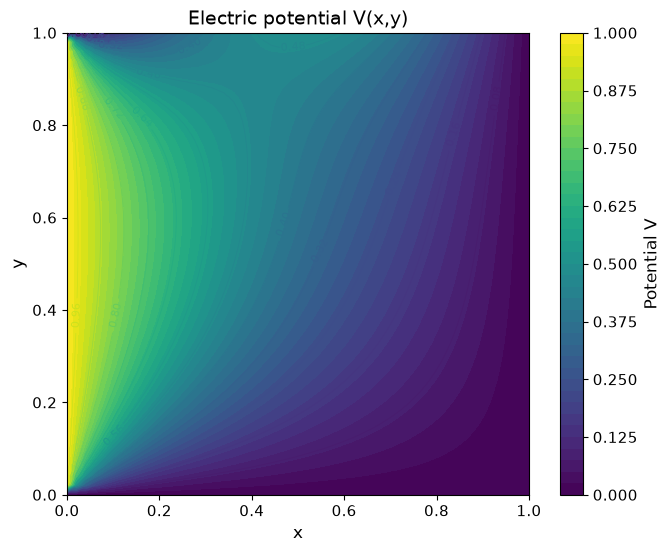

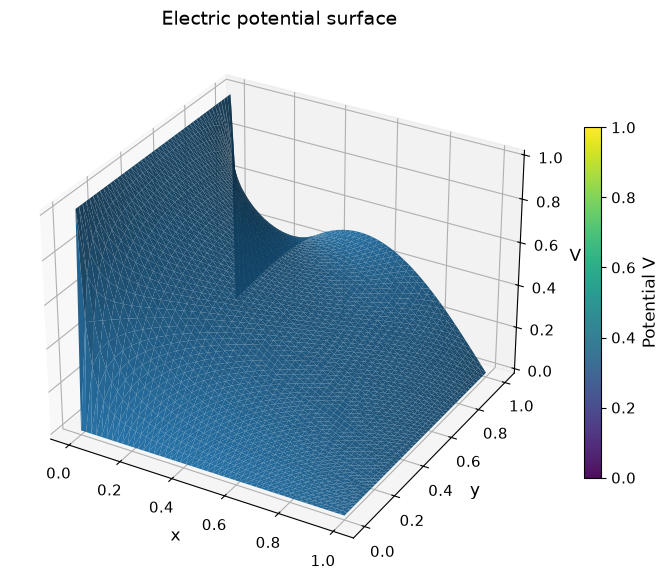

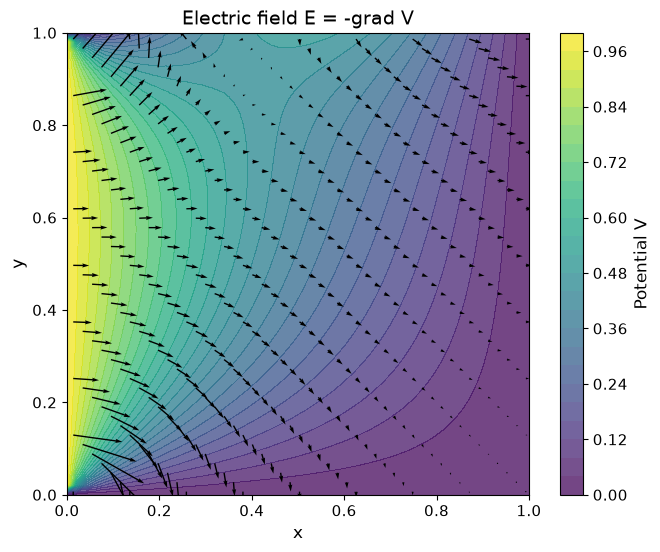

In [8]:
plot_potential_contour(points, triangles, V)
plot_potential_surface(points, triangles, V)
plot_electric_field(points, triangles, V, every=12)

## 9. Make a family of solutions

Now we generate a set of solutions by continuously varying one boundary-condition parameter.

Here we vary \(A_{\mathrm{top}}\), the amplitude of the sinusoidal voltage on the top wall.

Each solution is stored as one column in a matrix:

\[
S =
\begin{bmatrix}
| & | & & | \\
V_1 & V_2 & \cdots & V_m \\
| & | & & |
\end{bmatrix}.
\]

This is the **snapshot matrix** used in SVD/POD/reduced-basis methods.

In [9]:
def generate_snapshots_for_top_amplitude(
    points,
    boundary,
    K,
    A_values,
    base_params,
    boundary_voltage_func=example_boundary_voltage
):
    """
    Generate a snapshot matrix by varying A_top.

    Parameters
    ----------
    points, boundary, K
        Mesh and stiffness matrix objects.
    A_values : array-like
        Values of A_top to try.
    base_params : dict
        Base boundary-condition parameter dictionary.
    boundary_voltage_func : callable
        Boundary condition function.

    Returns
    -------
    snapshots : ndarray, shape (N_nodes, N_snapshots)
        Matrix whose columns are potential solutions.
    """
    snapshots = []

    for A in A_values:
        params_i = dict(base_params)
        params_i["A_top"] = float(A)

        V_i = solve_laplace_dirichlet_with_preassembled_K(
            K,
            points,
            boundary,
            boundary_voltage_func,
            params_i
        )

        snapshots.append(V_i)

    snapshots = np.column_stack(snapshots)
    return snapshots


A_values = np.linspace(-1.0, 1.0, 25)

snapshots = generate_snapshots_for_top_amplitude(
    points=points,
    boundary=boundary,
    K=K,
    A_values=A_values,
    base_params=params
)

print("Snapshot matrix shape:", snapshots.shape)

Snapshot matrix shape: (2500, 25)


## 10. SVD / POD preview

The singular value decomposition writes the snapshot matrix as

\[
S = U \Sigma W^T.
\]

The columns of \(U\) are spatial modes. The singular values in \(\Sigma\) tell us how important each mode is.

If the singular values decay quickly, it means that many different full solutions can be approximated using only a few basis functions. That is the model-order reduction treasure chest.

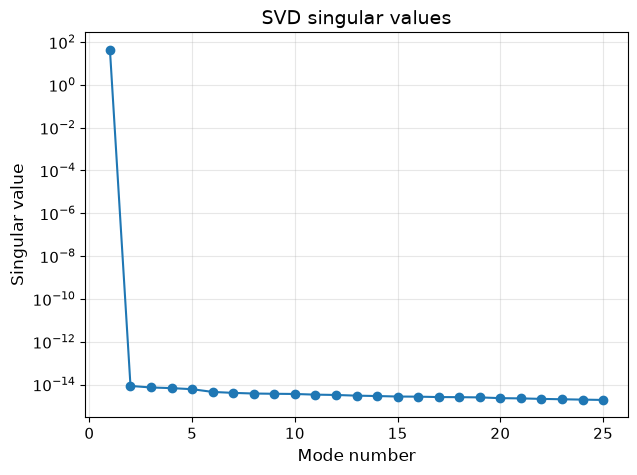

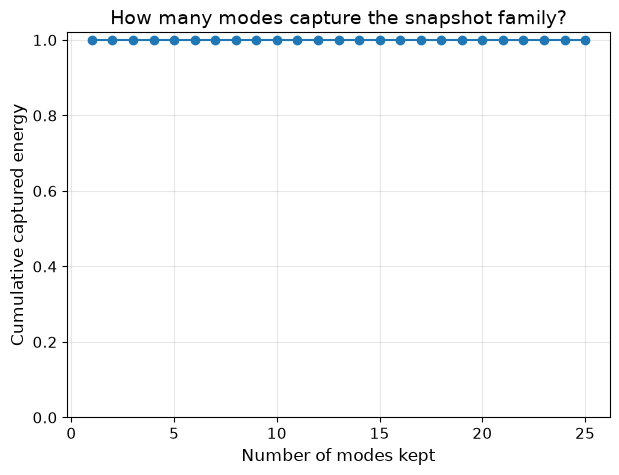

 1 modes capture 100.000000% of snapshot energy
 2 modes capture 100.000000% of snapshot energy
 3 modes capture 100.000000% of snapshot energy
 5 modes capture 100.000000% of snapshot energy
10 modes capture 100.000000% of snapshot energy


In [10]:
# Subtract the mean solution before SVD.
# This often makes the modes easier to interpret.
mean_snapshot = snapshots.mean(axis=1, keepdims=True)
snapshots_centered = snapshots - mean_snapshot

U, singular_values, Wt = np.linalg.svd(snapshots_centered, full_matrices=False)

energy = singular_values**2
relative_energy = energy / energy.sum()
cumulative_energy = np.cumsum(relative_energy)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(np.arange(1, len(singular_values) + 1), singular_values, "o-")
ax.set_xlabel("Mode number")
ax.set_ylabel("Singular value")
ax.set_title("SVD singular values")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.arange(1, len(cumulative_energy) + 1), cumulative_energy, "o-")
ax.set_xlabel("Number of modes kept")
ax.set_ylabel("Cumulative captured energy")
ax.set_ylim(0, 1.02)
ax.set_title("How many modes capture the snapshot family?")
ax.grid(True, alpha=0.3)
plt.show()

for r in [1, 2, 3, 5, 10]:
    if r <= len(cumulative_energy):
        print(f"{r:2d} modes capture {100*cumulative_energy[r-1]:.6f}% of snapshot energy")

## 11. Visualize the first few SVD modes

These modes are not voltages by themselves. They are spatial patterns that the snapshot solutions can combine.

The first mode is the most important direction of variation in the snapshot family, the second mode is the next most important, and so on.

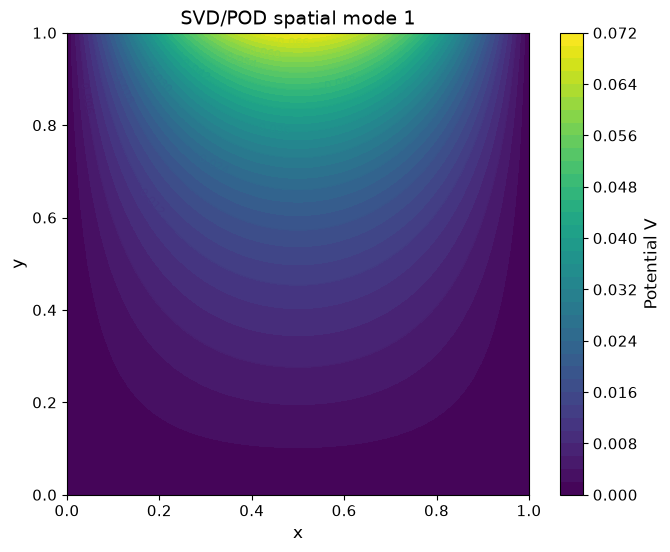

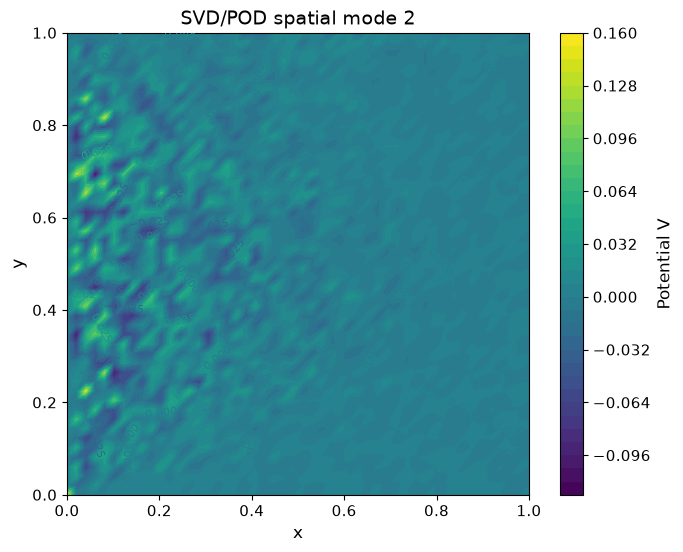

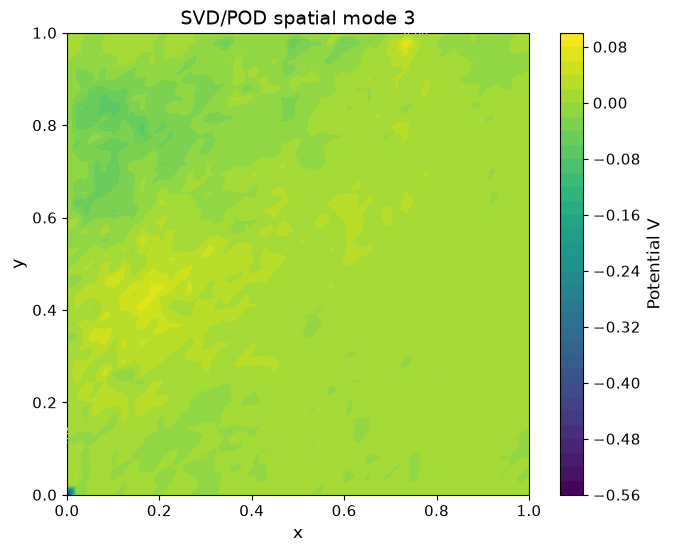

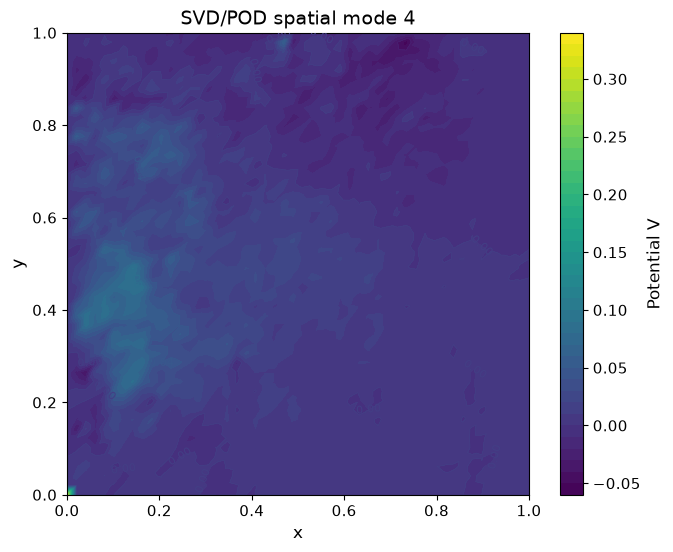

In [11]:
num_modes_to_plot = 4

for k in range(num_modes_to_plot):
    mode = U[:, k]
    plot_potential_contour(
        points,
        triangles,
        mode,
        title=f"SVD/POD spatial mode {k+1}"
    )

## 12. Reconstruct one solution using only a few modes

Here we approximate one full finite-element solution using a truncated SVD basis:

\[
V \approx \bar{V} + U_r c,
\]

where \(U_r\) contains only the first \(r\) modes.

This is the basic compression idea behind reduced-order modeling. In a full reduced-basis workflow, the next step is to compute or learn the coefficients \(c\) quickly for new boundary-condition parameters.

r =  1: relative reconstruction error = 2.051e-16


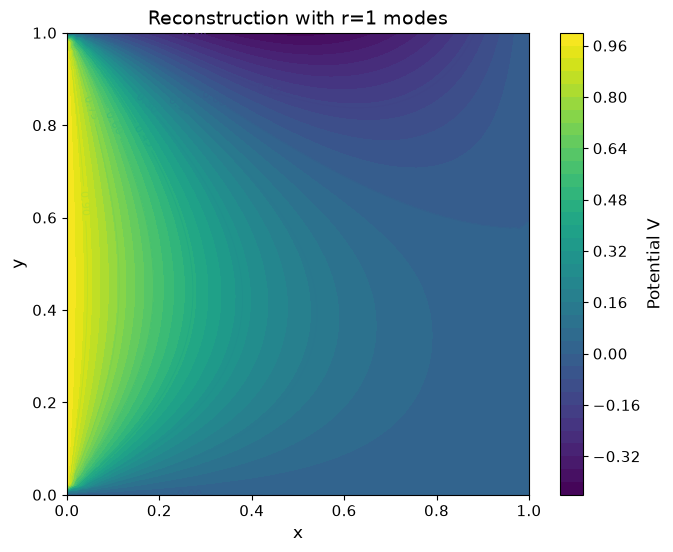

r =  2: relative reconstruction error = 1.799e-16


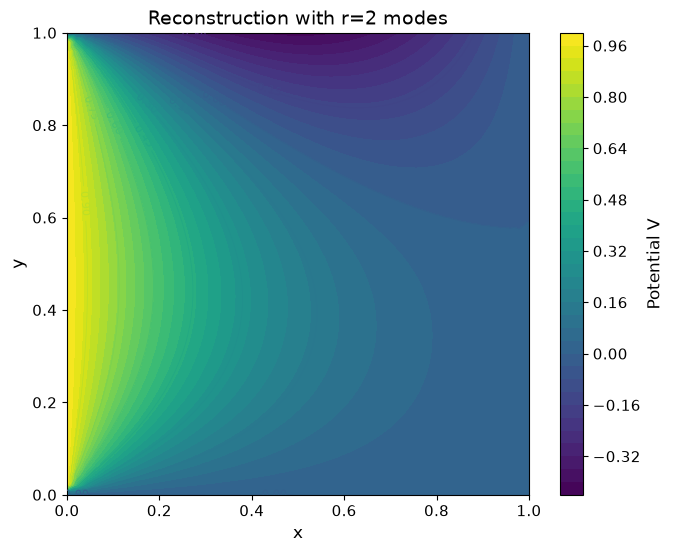

r =  3: relative reconstruction error = 1.825e-16


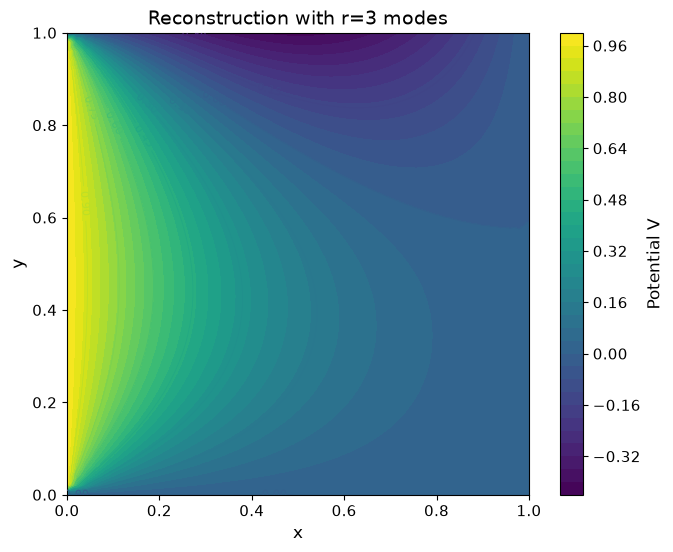

r =  5: relative reconstruction error = 2.391e-16


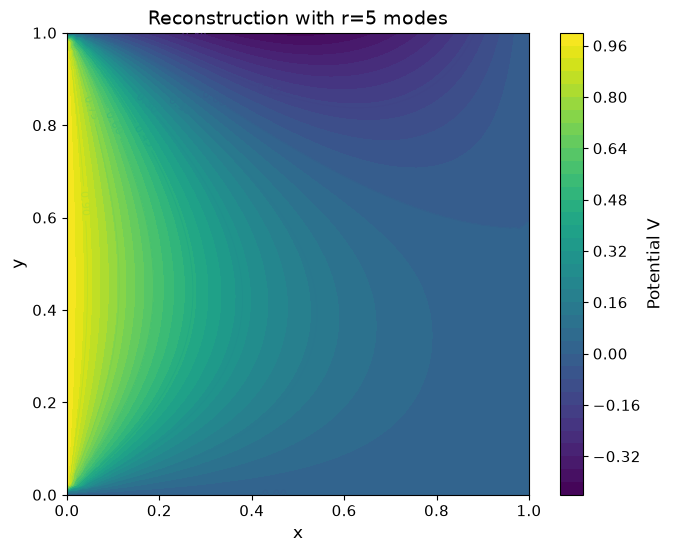

In [12]:
# Choose a snapshot to reconstruct.
snapshot_index = 7
V_true = snapshots[:, snapshot_index]

for r in [1, 2, 3, 5]:
    Ur = U[:, :r]

    # Projection coefficients.
    coeffs = Ur.T @ (V_true - mean_snapshot.ravel())

    # Reconstruction.
    V_recon = mean_snapshot.ravel() + Ur @ coeffs

    relative_error = np.linalg.norm(V_true - V_recon) / np.linalg.norm(V_true)

    print(f"r = {r:2d}: relative reconstruction error = {relative_error:.3e}")

    plot_potential_contour(
        points,
        triangles,
        V_recon,
        title=f"Reconstruction with r={r} modes"
    )

## 13. A more antenna-like boundary family

For future antenna-response emulation, it is useful to think of boundary conditions as controlled by a few physical knobs. Below is an example with two localized voltage bumps on the boundary.

This is still electrostatics, not a real antenna simulation. Real antenna modeling requires time-dependent Maxwell equations, waves, impedance, radiation, materials, and often open-boundary/radiation conditions. But this toy problem is a clean first chessboard for reduced-order ideas.

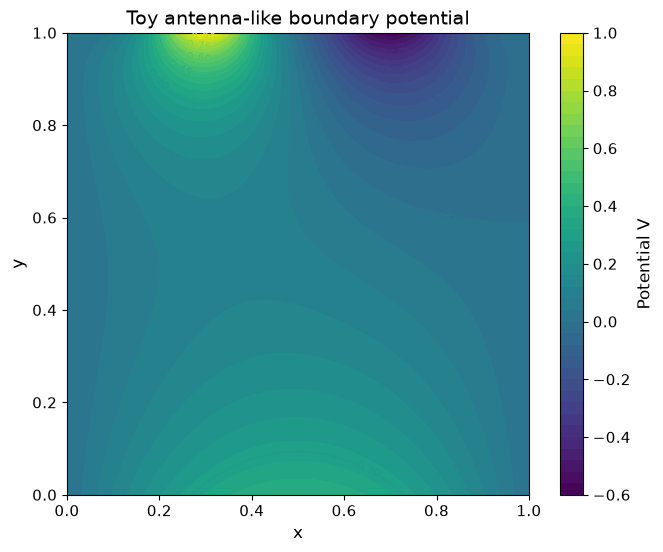

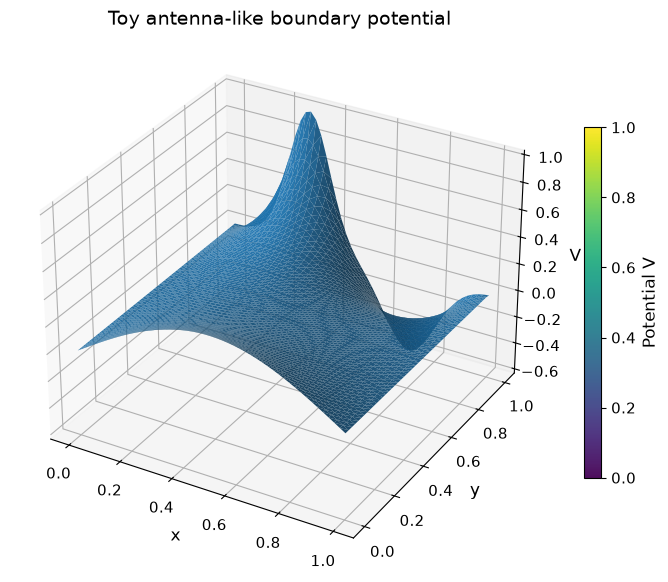

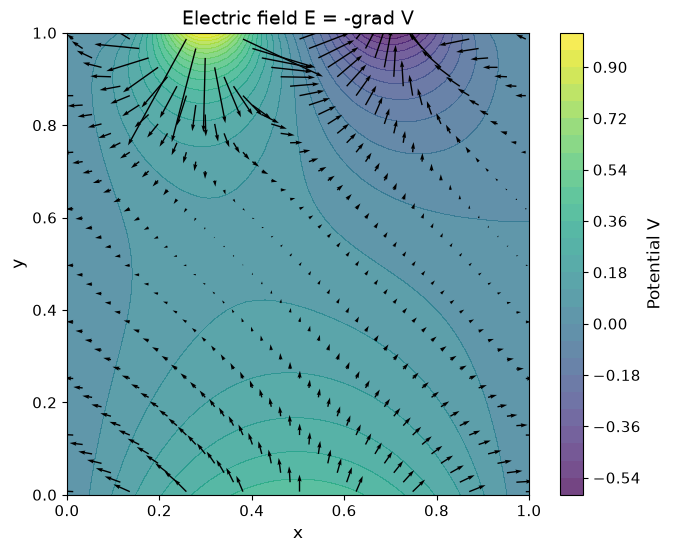

In [13]:
def gaussian_bump(x, center, width):
    """
    Smooth localized bump used to define boundary voltages.
    """
    return np.exp(-0.5 * ((x - center) / width)**2)


def antenna_like_boundary_voltage(x, y, params):
    """
    A toy boundary condition with localized voltage bumps.

    This is useful for generating a richer family of electrostatic solutions.

    Parameters in params
    --------------------
    left_voltage : float
        Constant voltage on left wall.
    right_voltage : float
        Constant voltage on right wall.
    top_amp_1, top_amp_2 : float
        Amplitudes of two Gaussian voltage bumps on the top wall.
    bottom_amp : float
        Amplitude of one sinusoidal bump on the bottom wall.
    """
    Lx = params.get("Lx", 1.0)
    Ly = params.get("Ly", 1.0)

    left_voltage = params.get("left_voltage", 0.0)
    right_voltage = params.get("right_voltage", 0.0)

    top_amp_1 = params.get("top_amp_1", 1.0)
    top_amp_2 = params.get("top_amp_2", -0.5)
    bottom_amp = params.get("bottom_amp", 0.0)

    x = np.asarray(x)
    y = np.asarray(y)
    V = np.zeros_like(x, dtype=float)

    tol = 1e-14
    on_left = np.isclose(x, 0.0, atol=tol)
    on_right = np.isclose(x, Lx, atol=tol)
    on_bottom = np.isclose(y, 0.0, atol=tol)
    on_top = np.isclose(y, Ly, atol=tol)

    V[on_left] = left_voltage
    V[on_right] = right_voltage

    V[on_bottom] = bottom_amp * np.sin(np.pi * x[on_bottom] / Lx)

    V[on_top] = (
        top_amp_1 * gaussian_bump(x[on_top], center=0.30 * Lx, width=0.08 * Lx)
        + top_amp_2 * gaussian_bump(x[on_top], center=0.70 * Lx, width=0.10 * Lx)
    )

    return V


antenna_params = {
    "Lx": Lx,
    "Ly": Ly,
    "left_voltage": 0.0,
    "right_voltage": 0.0,
    "top_amp_1": 1.0,
    "top_amp_2": -0.6,
    "bottom_amp": 0.4,
}

V_antenna_like = solve_laplace_dirichlet_with_preassembled_K(
    K,
    points,
    boundary,
    antenna_like_boundary_voltage,
    antenna_params
)

plot_potential_contour(points, triangles, V_antenna_like, title="Toy antenna-like boundary potential")
plot_potential_surface(points, triangles, V_antenna_like, title="Toy antenna-like boundary potential")
plot_electric_field(points, triangles, V_antenna_like, every=12)

## 14. Suggested next steps for the project

A good next ladder of difficulty:

1. **Generate snapshots** by varying several boundary-condition parameters.
2. Use **SVD/POD** to build a reduced basis.
3. Try interpolation or regression from boundary parameters to reduced coefficients.
4. Compare full FEM solutions to reduced-basis reconstructions.
5. Add **Poisson's equation** with charge density:
   \[
   \nabla^2 V = -\rho/\epsilon_0.
   \]
6. Move to more realistic electromagnetic problems:
   - Helmholtz equation,
   - frequency-domain Maxwell equations,
   - materials with permittivity \(\epsilon(\mathbf{x})\),
   - absorbing/radiation boundary conditions,
   - antenna ports and impedance.

For now, this notebook gives you the little electrostatic seed crystal: a full-order solver, parameterized boundary conditions, pretty fields, and an SVD door into reduced-order modeling.